# Homework Week 2 - Probability and Statistics for AI

This notebook uses the Iris dataset.

The goal is to practice descriptive statistics, probability distributions, correlation analysis, and Bayes' theorem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = [iris.target_names[i] for i in iris.target]

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
(150, 5)
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


## 1. Descriptive statistics

For each numeric variable, we compute mean, median, mode, variance, standard deviation, min, max, Q1, Q3, and IQR.

IQR is computed as:

IQR = Q3 - Q1

In [3]:
numeric_cols = df.select_dtypes(include="number").columns

stats_summary = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode": df[numeric_cols].mode().iloc[0],
    "var": df[numeric_cols].var(),
    "std": df[numeric_cols].std(),
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q3": df[numeric_cols].quantile(0.75)
})

stats_summary["IQR"] = stats_summary["Q3"] - stats_summary["Q1"]

stats_summary.round(3)

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal length (cm),5.843,5.80,5.0,0.686,0.828,4.3,7.9,5.1,6.4,1.3
sepal width (cm),3.057,3.00,3.0,0.190,0.436,2.0,4.4,2.8,3.3,0.5
petal length (cm),3.758,4.35,1.4,3.116,1.765,1.0,6.9,1.6,5.1,3.5
petal width (cm),1.199,1.30,0.2,0.581,0.762,0.1,2.5,0.3,1.8,1.5


## 2. Statistics by species

We group the dataset by species and compute the mean and standard deviation for each numeric variable.

In [4]:
group_stats = df.groupby("species")[numeric_cols].agg(["mean", "std"])

group_stats.round(3)

sepal length (cm)        sepal width (cm)        petal length (cm)  \
                        mean    std             mean    std              mean   
species                                                                         
setosa                 5.006  0.352            3.428  0.379             1.462   
versicolor             5.936  0.516            2.770  0.314             4.260   
virginica              6.588  0.636            2.974  0.322             5.552   

                  petal width (cm)         
              std             mean    std  
species                                    
setosa      0.174            0.246  0.105  
versicolor  0.470            1.326  0.198  
virginica   0.552            2.026  0.275

### Observation

The setosa species is clearly different from the other two species in petal length and petal width.  
Its petal measurements are much smaller.

Versicolor and virginica are closer to each other, but virginica generally has larger petal length and petal width.

# 3. Probability distributions

In this section, we visualize the distribution of each numeric variable.

We use histogram and KDE plots to observe the shape of each distribution.  
Then we use boxplots to compare distributions across species.

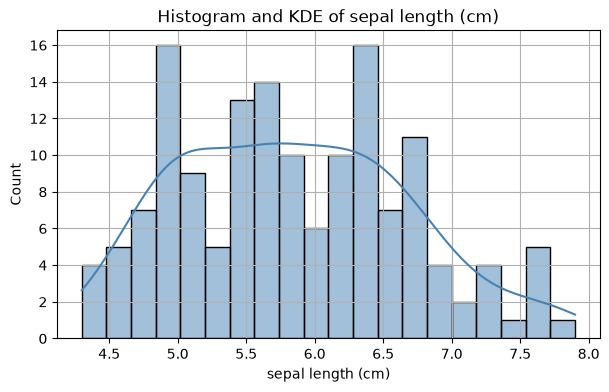

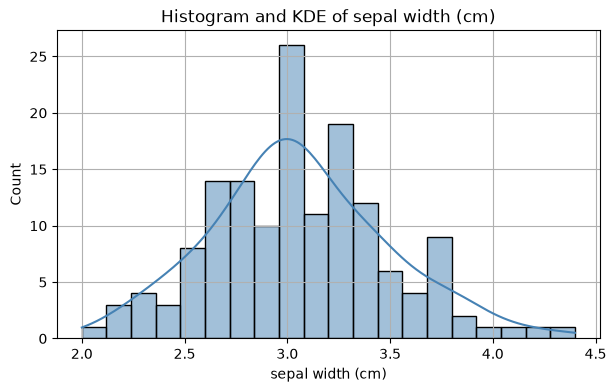

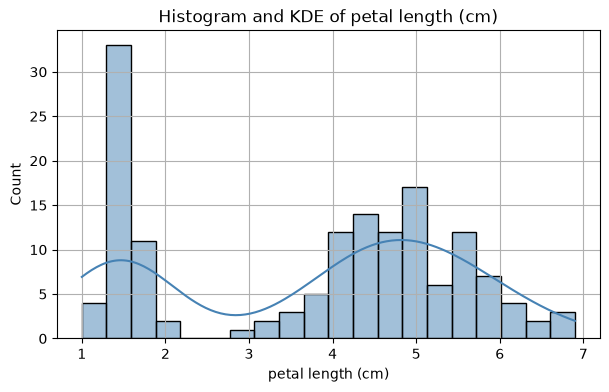

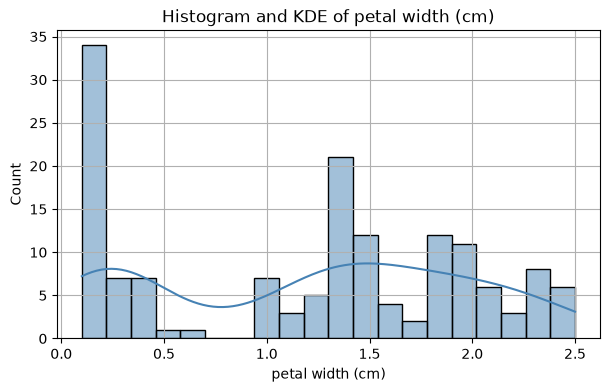

In [5]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=20, color="steelblue")
    plt.title(f"Histogram and KDE of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

### Histogram and KDE observation

The petal length and petal width distributions are not close to a single normal distribution.  
They show separated groups because the Iris dataset contains three species.

Sepal length is closer to a bell-shaped distribution, but it is still affected by species groups.  
Sepal width is more concentrated around its center.

## 4. Boxplot by species

Boxplots help compare each numeric variable across the three Iris species.

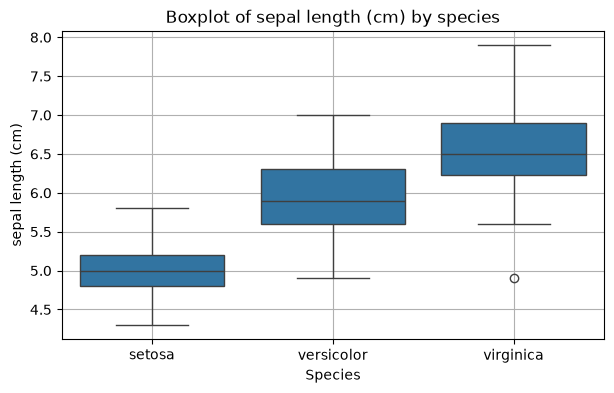

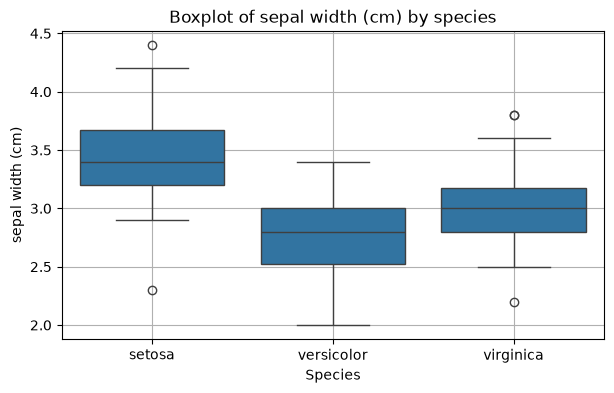

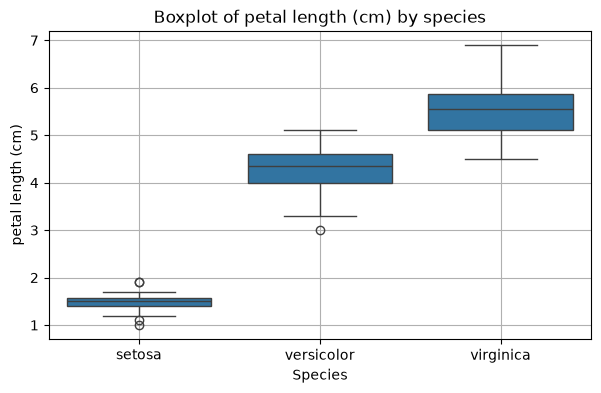

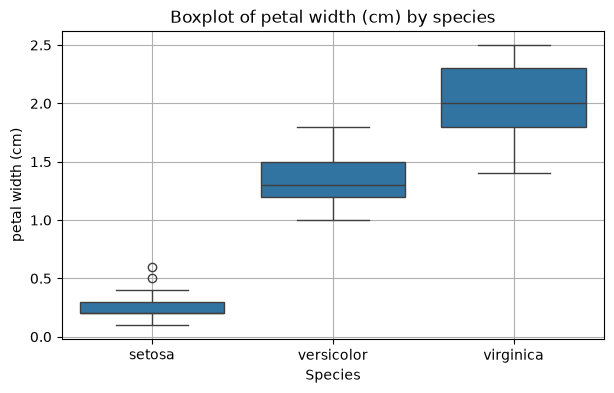

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="species", y=col)
    plt.title(f"Boxplot of {col} by species")
    plt.xlabel("Species")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

### Boxplot observation

Setosa is clearly separated from the other two species in petal length and petal width.  
Its petal measurements are much smaller.

Versicolor and virginica are closer to each other, but virginica generally has larger petal length and petal width.

## 5. Normal distribution simulation

We choose petal length as an example variable.

We generate samples from a normal distribution with the same mean and standard deviation as the real data.  
Then we compare the real distribution with the theoretical normal PDF.

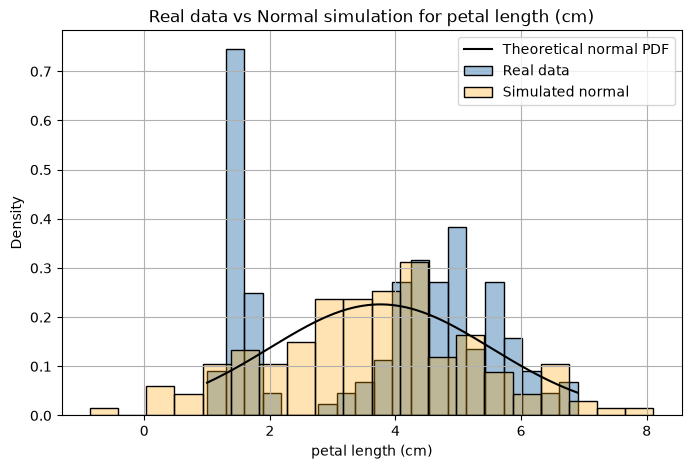

Mean: 3.758
Standard deviation: 1.765


In [7]:
col = "petal length (cm)"

mu = df[col].mean()
sigma = df[col].std()

np.random.seed(42)
normal_samples = np.random.normal(mu, sigma, size=len(df))

x_values = np.linspace(df[col].min(), df[col].max(), 300)
normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_values - mu) / sigma) ** 2
)

plt.figure(figsize=(8, 5))

sns.histplot(df[col], bins=20, stat="density", alpha=0.5, label="Real data", color="steelblue")
sns.histplot(normal_samples, bins=20, stat="density", alpha=0.3, label="Simulated normal", color="orange")

plt.plot(x_values, normal_pdf, label="Theoretical normal PDF", color="black")

plt.title(f"Real data vs Normal simulation for {col}")
plt.xlabel(col)
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

print("Mean:", round(mu, 3))
print("Standard deviation:", round(sigma, 3))

### Normal simulation observation

The normal distribution does not match petal length perfectly.

The real petal length distribution has separated groups because the dataset contains three species.  
A single normal distribution cannot represent these groups well.

This shows that checking the distribution shape is important before assuming normality.

# 6. Multivariate analysis and correlation

In this section, we compute the covariance matrix and correlation matrix between numeric variables.

Correlation helps measure the strength and direction of linear relationships between variables.

In [8]:
cov_matrix = df[numeric_cols].cov()
corr_matrix = df[numeric_cols].corr()

print("Covariance matrix:")
display(cov_matrix.round(3))

print("Correlation matrix:")
display(corr_matrix.round(3))

Covariance matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.686,-0.042,1.274,0.516
sepal width (cm),-0.042,0.190,-0.330,-0.122
petal length (cm),1.274,-0.330,3.116,1.296
petal width (cm),0.516,-0.122,1.296,0.581


Correlation matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,-0.118,0.872,0.818
sepal width (cm),-0.118,1.000,-0.428,-0.366
petal length (cm),0.872,-0.428,1.000,0.963
petal width (cm),0.818,-0.366,0.963,1.000


## 7. Correlation heatmap

The heatmap shows the correlation values between numeric variables.

Values close to 1 indicate strong positive correlation.  
Values close to -1 indicate strong negative correlation.  
Values close to 0 indicate weak linear correlation.

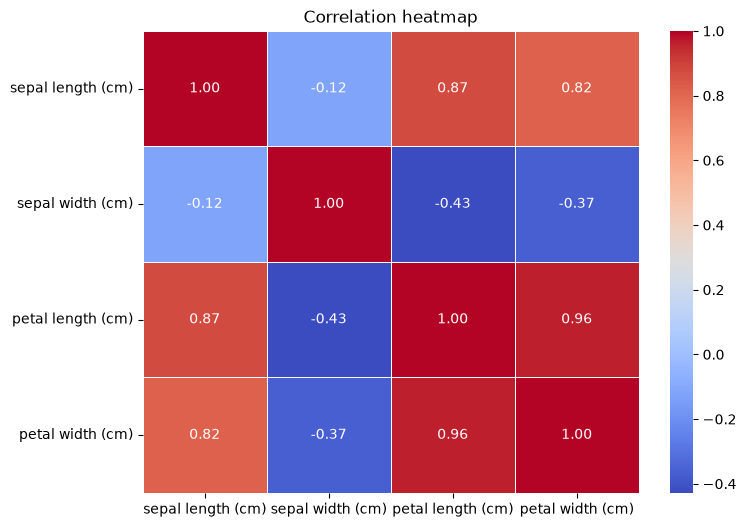

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation heatmap")
plt.show()

In [10]:
corr_abs = corr_matrix.abs().copy()

for i in range(len(corr_abs)):
    corr_abs.iloc[i, i] = 0

max_pair = np.unravel_index(
    np.argmax(corr_abs.to_numpy()),
    corr_abs.shape
)

var1 = corr_abs.index[max_pair[0]]
var2 = corr_abs.columns[max_pair[1]]
max_corr = corr_matrix.loc[var1, var2]

print("Strongest correlated pair:")
print(var1, "and", var2)
print("Correlation:", round(max_corr, 3))

Strongest correlated pair:
petal length (cm) and petal width (cm)
Correlation: 0.963


### Correlation observation

The strongest correlation is usually between petal length and petal width.  
This means flowers with longer petals also tend to have wider petals.

There is a sign of multicollinearity between petal length and petal width because their correlation is very high.  
If both variables are used in a linear model, they may provide overlapping information.

## 8. Pairplot by species

The pairplot shows pairwise relationships between numeric variables.  
The points are colored by species.

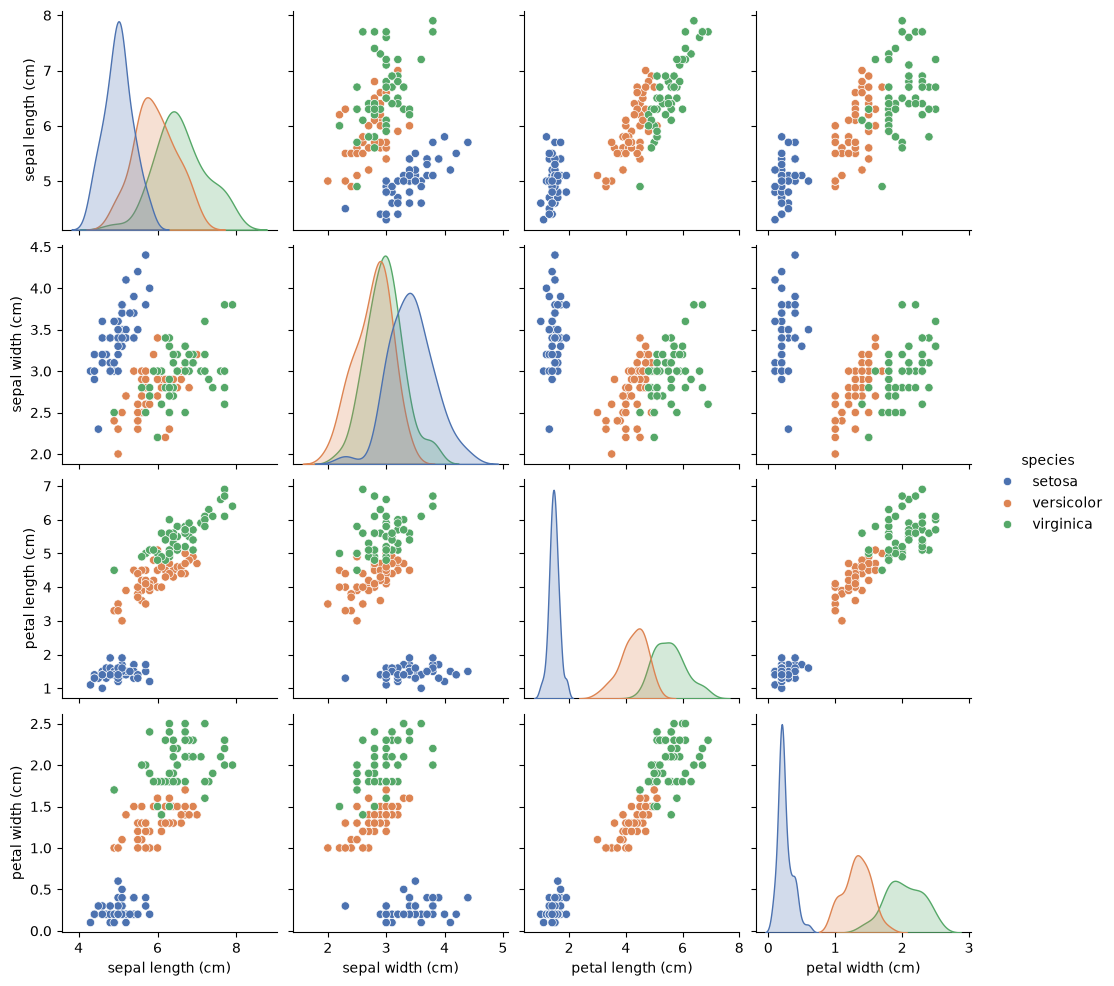

In [11]:
sns.pairplot(df, hue="species", diag_kind="kde", palette="deep")
plt.show()

### Pairplot observation

The pairplot shows that setosa is clearly separated from the other species, especially using petal length and petal width.

Versicolor and virginica overlap more than setosa, but they still show some separation in petal measurements.

Petal length and petal width form a strong positive relationship, which matches the correlation heatmap.

# 9. Bayes' theorem

We use Bayes' theorem to compute the probability that a person has a disease after receiving a positive test result.

Given:

- P(B) = 0.01
- P(+ | B) = 0.99
- P(+ | not B) = 0.05

In [12]:
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_not_B = 0.05

P_not_B = 1 - P_B

P_pos = P_pos_given_B * P_B + P_pos_given_not_B * P_not_B
P_B_given_pos = P_pos_given_B * P_B / P_pos

print("P(+):", round(P_pos, 4))
print("P(B | +):", round(P_B_given_pos, 4))

P(+): 0.0594
P(B | +): 0.1667


## 10. Bayes sensitivity to disease prevalence

We vary the disease prevalence P(B) from 0.001 to 0.2 and observe how P(B | +) changes.

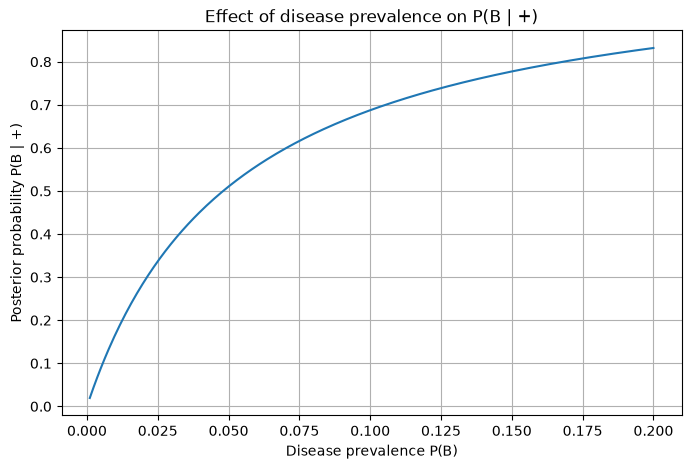

In [13]:
prevalences = np.linspace(0.001, 0.2, 300)

posterior_probs = []

for P_B in prevalences:
    P_not_B = 1 - P_B
    P_pos = P_pos_given_B * P_B + P_pos_given_not_B * P_not_B
    P_B_given_pos = P_pos_given_B * P_B / P_pos
    posterior_probs.append(P_B_given_pos)

plt.figure(figsize=(8, 5))
plt.plot(prevalences, posterior_probs)

plt.xlabel("Disease prevalence P(B)")
plt.ylabel("Posterior probability P(B | +)")
plt.title("Effect of disease prevalence on P(B | +)")
plt.grid(True)
plt.show()

### Bayes observation

When the disease is rare, a positive test result can still have a low posterior probability.

This happens because false positives can outnumber true positives in a large healthy population.  
Even with high sensitivity, the base rate P(B) strongly affects P(B | +).

As disease prevalence increases, P(B | +) also increases.

# 11. Bonus: Simple Naive Bayes spam filter

This section builds a small keyword-based Naive Bayes spam filter.

We define a few keywords and estimate whether an email is spam based on the words it contains.

In [14]:
spam_keywords = {
    "win": 0.8,
    "free": 0.9,
    "money": 0.85,
    "prize": 0.8,
    "urgent": 0.7
}

ham_keywords = {
    "meeting": 0.8,
    "project": 0.7,
    "homework": 0.75,
    "class": 0.7,
    "schedule": 0.65
}

P_spam = 0.4
P_ham = 0.6


def naive_bayes_email(email):
    words = email.lower().split()

    spam_score = P_spam
    ham_score = P_ham

    for word in words:
        if word in spam_keywords:
            spam_score *= spam_keywords[word]
        else:
            spam_score *= 0.2

        if word in ham_keywords:
            ham_score *= ham_keywords[word]
        else:
            ham_score *= 0.2

    total = spam_score + ham_score
    P_spam_given_email = spam_score / total

    return P_spam_given_email


emails = [
    "win free money",
    "project meeting schedule",
    "urgent homework class"
]

for email in emails:
    prob = naive_bayes_email(email)
    label = "spam" if prob >= 0.5 else "not spam"
    print(email, "| P(spam | email) =", round(prob, 4), "|", label)

win free money | P(spam | email) = 0.9808 | spam
project meeting schedule | P(spam | email) = 0.0144 | not spam
urgent homework class | P(spam | email) = 0.1509 | not spam


### Bonus observation

The simple Naive Bayes filter gives high spam probability to emails with words such as "win", "free", and "money".

Emails with words such as "project", "meeting", and "schedule" are classified as not spam.

This is a simplified example. A real spam filter needs more training data, better word probabilities, and text preprocessing.